<a href="https://colab.research.google.com/github/B-DS-Research/B6_Research/blob/main/RMDS_Hackathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seasonal Vaccine Prediction Notebook

This notebook demonstrates a complete machine learning workflow to predict seasonal vaccine uptake, including data loading, exploratory data analysis, preprocessing, model training, evaluation, hyperparameter tuning, explainable AI, and submission generation.

In [37]:
!pip install xgboost lightgbm catboost shap missingno --quiet

## Setup and Imports

This section handles installing necessary libraries and importing all required modules for data manipulation, visualization, machine learning, and explainable AI.

#Importing all the required libraries

In [38]:
import warnings, os, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import shap

from datetime import datetime

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import *
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    ExtraTreesClassifier, ExtraTreesRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor
)

from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor


# For explanatory good plots

In [39]:
# Set a consistent theme for all plots
sns.set_theme(style="whitegrid", font_scale=1.1)

# Configure global matplotlib parameters for better readability
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titleweight"] = "bold"

# Create necessary directories if they don't already exist
for folder in ["figures", "submissions", "outputs", "documentation"]:
    os.makedirs(folder, exist_ok=True)

### Plotting Configuration and Output Directories

Sets up default plotting styles using seaborn and matplotlib, and creates directories for saving figures, submissions, outputs, and documentation.

## Dataset and Key Columns

In [40]:
from google.colab import drive
drive.mount('/content/drive')
# Define paths to the training and testing datasets
TRAIN_PATH = "/content/dataset_A_training.csv"
TEST_PATH = "/content/dataset_A_testing.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
TRAIN_PATH =  "/content/drive/MyDrive/Dataset A/dataset_A_training.csv"
TEST_PATH =  "/content/drive/MyDrive/Dataset A/dataset_A_testing.csv"

## Loading Data

### Load Datasets

Loads the training and testing datasets from the specified CSV files into pandas DataFrames and displays their shapes and the first few rows for initial inspection.

In [42]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

display(train_df.head())
display(test_df.head())

Training shape: (4756, 31)
Testing shape: (4749, 30)


,respondent_id,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,seasonal_vaccine
0,1,2.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,0.0,0.0,entertainment,0
1,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Male,NaN,Not Married,Rent,Employed,"MSA, Principle City",1.0,0.0,education,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,...,Male,"> $75,000",Married,Own,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,NaN,0
3,4,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Male,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",1.0,2.0,utilities,1
4,5,2.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,Female,Below Poverty,Not Married,Rent,Not in Labor Force,"MSA, Not Principle City",2.0,0.0,NaN,0


,respondent_id,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector
0,4757,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,"MSA, Principle City",0.0,0.0,NaN
1,4758,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,White,Female,NaN,NaN,NaN,NaN,"MSA, Not Principle City",0.0,0.0,NaN
2,4759,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,White,Male,NaN,Married,Own,Not in Labor Force,"MSA, Principle City",1.0,0.0,NaN
3,4760,3.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,1.0,0.0,agriculture
4,4761,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,Non-MSA,0.0,0.0,wholesale


## Team Log and Project Overview

This section defines key project information, team member roles, workflow steps, and GitHub notes. This information is then saved to a JSON file for documentation.

## Team Logs

In [43]:
TARGET = "seasonal_vaccine"
ID_COL = "respondent_id"

team_log = {
    "project": "RMDS Hackathon - Seasonal Vaccine Prediction",
    "created_at": str(datetime.now()),
    "target": TARGET,
    "task_type": "Binary Classification",
    "team_members": [
        "Tarun - EDA, modelling, final review",
        "Member 2 - preprocessing",
        "Member 3 - visualisations",
        "Member 4 - baseline models",
        "Member 5 - advanced models",
        "Member 6 - tuning and submissions",
        "Member 7 - XAI and presentation"
    ],
    "workflow": [
        "Data exploration",
        "Missing value analysis",
        "Preprocessing",
        "Model training",
        "Cross-validation",
        "Hyperparameter tuning",
        "Explainable AI",
        "Submission generation"
    ],
    "github_notes": [
        "Commit regularly every 20-30 minutes",
        "Use meaningful commit messages",
        "Upload notebook and outputs to GitHub",
        "Include GitHub and Colab links on first presentation slide"
    ]
}

with open("documentation/teamwork_log.json", "w") as f:
    json.dump(team_log, f, indent=4)

## Basic Data Exploration

This section performs initial exploration of the datasets, including checking column names, data types, non-null counts, and descriptive statistics. It also saves a summary of the dataset overview to a JSON file.

## Basic Data Eploration

In [44]:
# Print column names for both training and testing datasets
print("Training columns:")
print(train_df.columns.tolist())

print("\nTesting columns:")
print(test_df.columns.tolist())

# Display concise summary of the DataFrame including data types and non-null values
display(train_df.info())
# Display descriptive statistics for all columns, including object types
display(train_df.describe(include="all").T)

# Create an overview dictionary for documentation
overview = {
    "training_rows": int(train_df.shape[0]),
    "training_columns": int(train_df.shape[1]),
    "testing_rows": int(test_df.shape[0]),
    "testing_columns": int(test_df.shape[1]),
    "target": TARGET,
    "id_column": ID_COL
}

# Save the overview to a JSON file
with open("outputs/dataset_overview.json", "w") as f:
    json.dump(overview, f, indent=4)

Training columns:
['respondent_id', 'flu_concern', 'flu_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_seasonal', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'household_adults', 'household_children', 'employment_sector', 'seasonal_vaccine']

Testing columns:
['respondent_id', 'flu_concern', 'flu_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_seasonal', 'chronic_med_condition', 'child_under_6_months', 'health_worker', '

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
respondent_id,4756.0,NaN,NaN,NaN,2378.5,1373.08327,1.0,1189.75,2378.5,3567.25,4756.0
flu_concern,4744.0,NaN,NaN,NaN,1.643128,0.91981,0.0,1.0,2.0,2.0,3.0
flu_knowledge,4733.0,NaN,NaN,NaN,1.293049,0.618902,0.0,1.0,1.0,2.0,2.0
behavioral_antiviral_meds,4742.0,NaN,NaN,NaN,0.052299,0.222652,0.0,0.0,0.0,0.0,1.0
behavioral_avoidance,4724.0,NaN,NaN,NaN,0.734124,0.441846,0.0,0.0,1.0,1.0,1.0
behavioral_face_mask,4753.0,NaN,NaN,NaN,0.073848,0.261551,0.0,0.0,0.0,0.0,1.0
behavioral_wash_hands,4748.0,NaN,NaN,NaN,0.836563,0.369803,0.0,1.0,1.0,1.0,1.0
behavioral_large_gatherings,4747.0,NaN,NaN,NaN,0.365494,0.481619,0.0,0.0,0.0,1.0,1.0
behavioral_outside_home,4747.0,NaN,NaN,NaN,0.336634,0.472608,0.0,0.0,0.0,1.0,1.0
behavioral_touch_face,4737.0,NaN,NaN,NaN,0.68841,0.463192,0.0,0.0,1.0,1.0,1.0


## Missing Value Analysis

### Missing Value Analysis

This section identifies and visualizes missing values in the training dataset. It generates a summary table of missing counts and percentages, a bar plot of top missing features, and a matrix plot for a visual overview of missing data patterns.

In [45]:
# Calculate missing counts and percentages for each column
missing_summary = pd.DataFrame({
    "Missing Count": train_df.isnull().sum(),
    "Missing %": train_df.isnull().mean() * 100
}).sort_values("Missing %", ascending=False)

# Display the missing summary and save it to CSV
display(missing_summary)
missing_summary.to_csv("outputs/missing_summary.csv")

# Filter for columns with any missing values and get the top 20
top_missing = missing_summary[missing_summary["Missing %"] > 0].head(20)

,Missing Count,Missing %
employment_sector,2314,48.654331
health_insurance,1925,40.475189
income_poverty,790,16.610597
rent_or_own,381,8.010934
doctor_recc_seasonal,321,6.749369
education,270,5.677040
employment_status,269,5.656013
marital_status,265,5.571909
chronic_med_condition,188,3.952902
child_under_6_months,152,3.195963


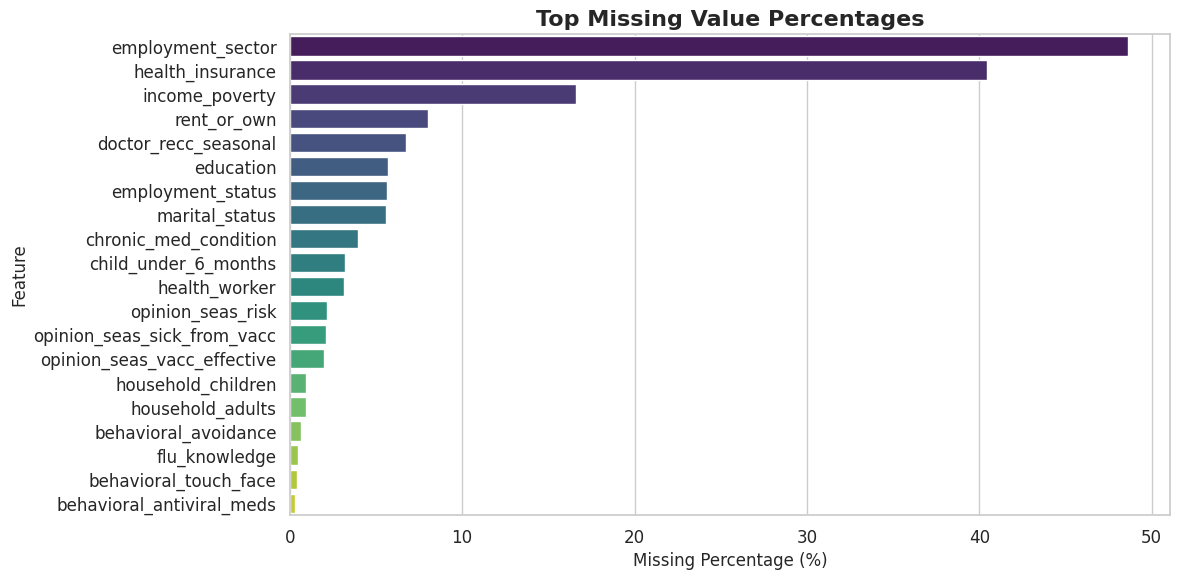

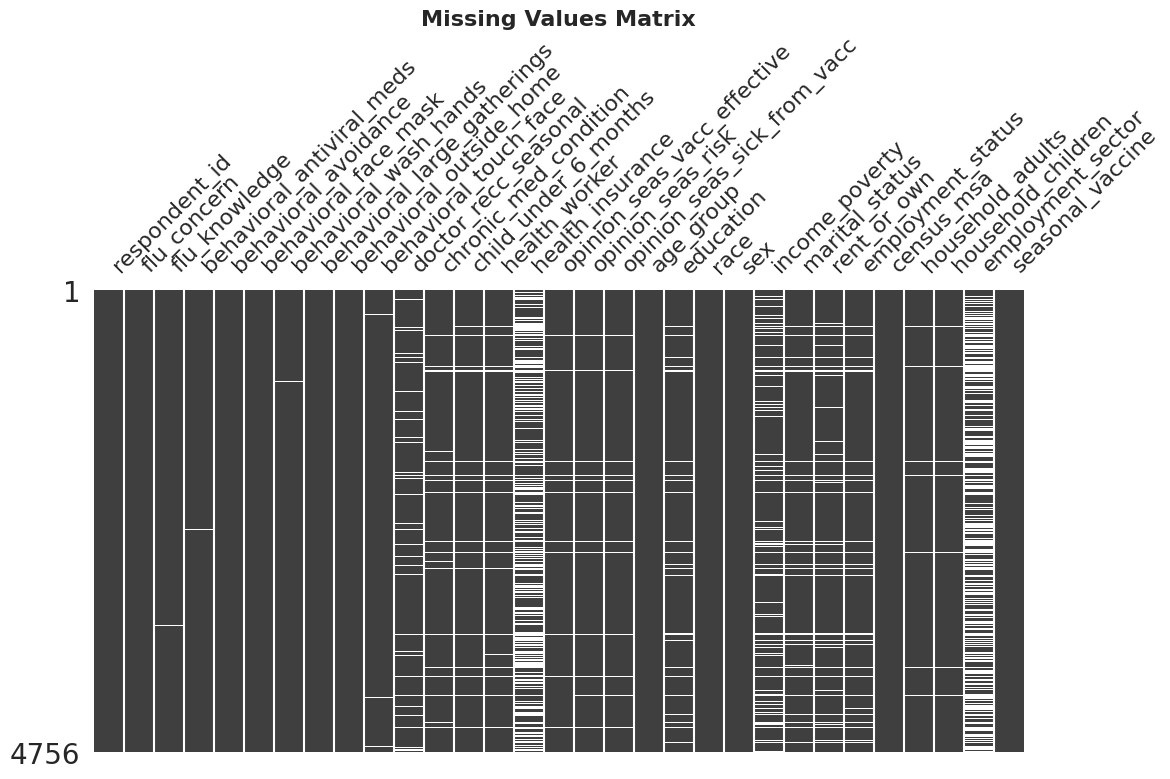

In [46]:
if len(top_missing) > 0:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_missing["Missing %"], y=top_missing.index, palette="viridis")
    plt.title("Top Missing Value Percentages")
    plt.xlabel("Missing Percentage (%)")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig("figures/missing_values_bar.png", dpi=300)
    plt.show()

# Generate a matrix plot to visualize the distribution of missing values across features
msno.matrix(train_df, figsize=(12, 6), sparkline=False)
plt.title("Missing Values Matrix", fontsize=16, fontweight="bold")
plt.savefig("figures/missing_matrix.png", dpi=300)
plt.show()

## Target Variable Analysis

## Target Variable Analysis

This section analyzes the distribution of the target variable (`seasonal_vaccine`). It generates a count plot to visualize the class balance and prints the percentage distribution of each class, saving it to a CSV.

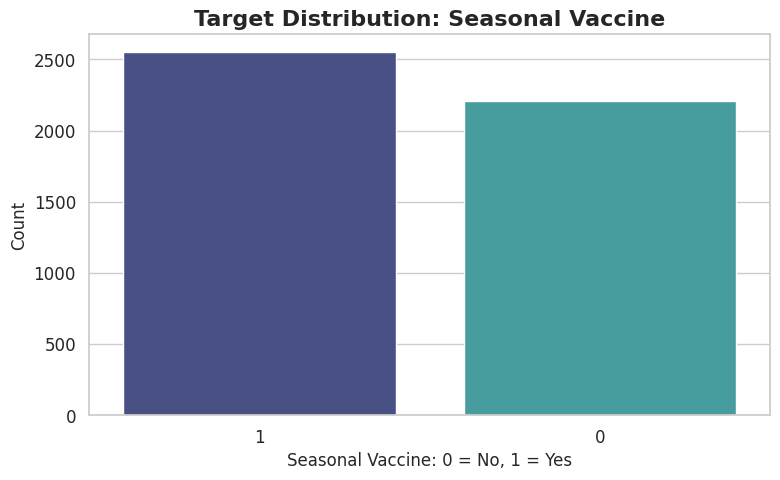

Class balance percentage:


,proportion
seasonal_vaccine,
1,53.637511
0,46.362489


In [47]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=train_df,
    x=TARGET,
    order=train_df[TARGET].value_counts().index,
    palette="mako"
)
plt.title("Target Distribution: Seasonal Vaccine")
plt.xlabel("Seasonal Vaccine: 0 = No, 1 = Yes")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("figures/target_distribution.png", dpi=300)
plt.show()

# Calculate and print the percentage balance of the target classes
class_balance = train_df[TARGET].value_counts(normalize=True) * 100
print("Class balance percentage:")
display(class_balance)
class_balance.to_csv("outputs/class_balance.csv")

# Feature Type Identification

### Feature Type Identification

This code categorizes features into numerical and categorical types based on their data types. It then removes the target and ID columns from these lists, providing a clear distinction for further preprocessing steps.

In [48]:
# Identify numerical columns (excluding the target and ID)
num_cols = train_df.select_dtypes(include=np.number).columns.tolist()
# Identify categorical columns (excluding the target and ID)
cat_cols = train_df.select_dtypes(exclude=np.number).columns.tolist()

# Remove TARGET and ID_COL from numerical and categorical lists if present
for col in [TARGET, ID_COL]:
    if col in num_cols:
        num_cols.remove(col)
    if col in cat_cols:
        cat_cols.remove(col)

print("Numerical columns:", len(num_cols))
print(num_cols)

print("Categorical columns:", len(cat_cols))
print(cat_cols)

Numerical columns: 19
['flu_concern', 'flu_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_seasonal', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'household_adults', 'household_children']
Categorical columns: 10
['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'employment_sector']


## Numerical Feature EDA

### Numerical Feature EDA

This section visualizes the distribution and identifies outliers for all numerical features. It generates histogram plots to show distributions and box plots to highlight outliers, saving each plot as a PNG image.

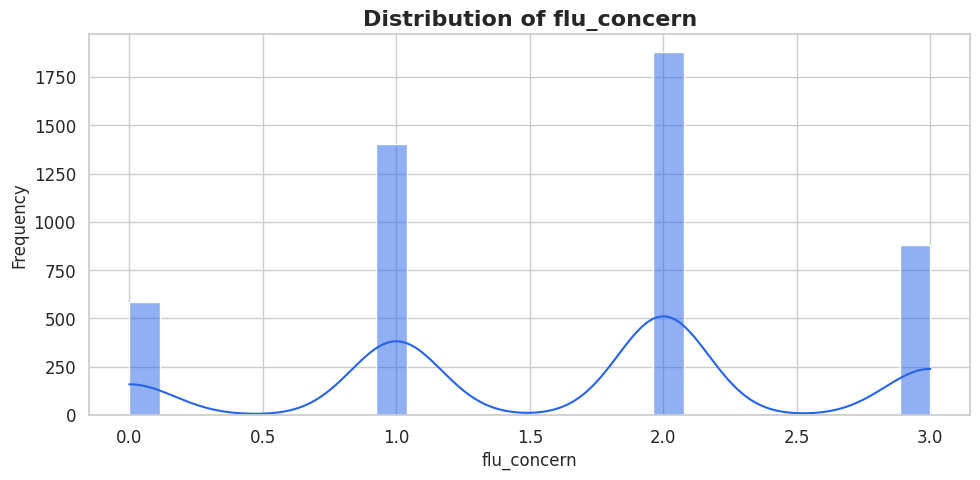

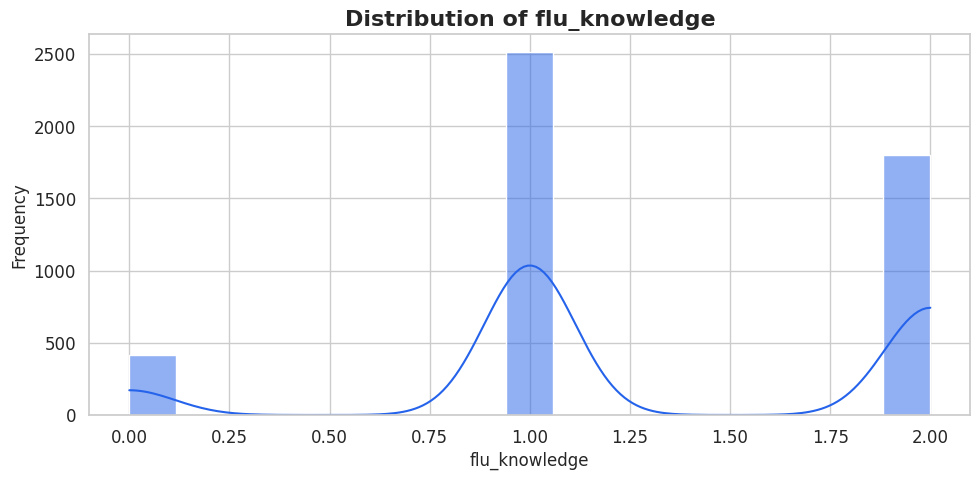

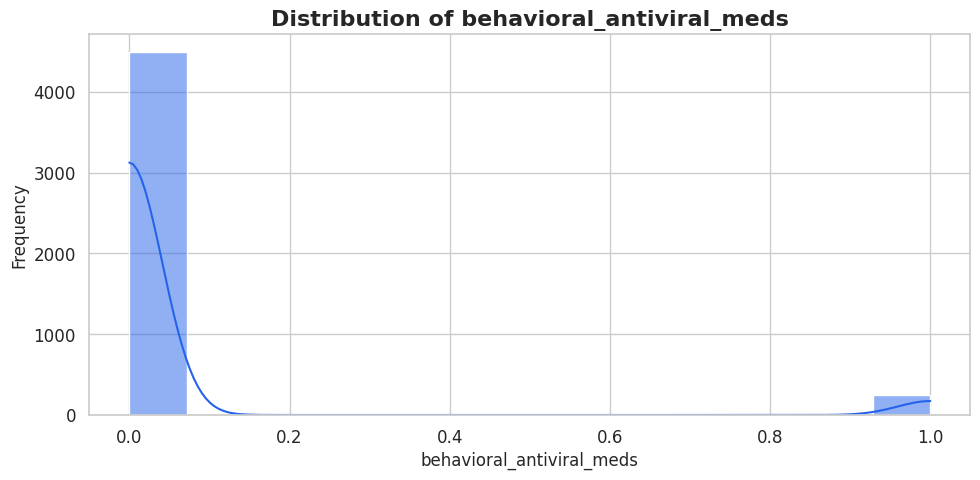

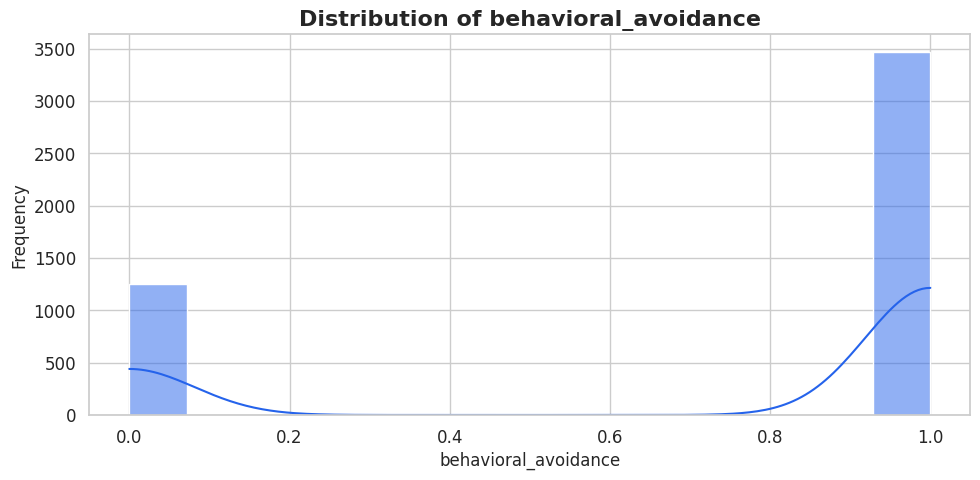

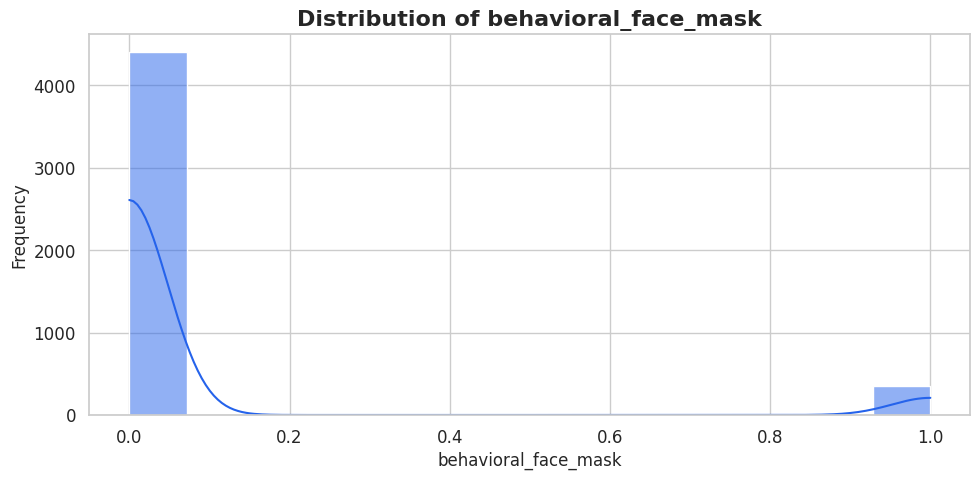

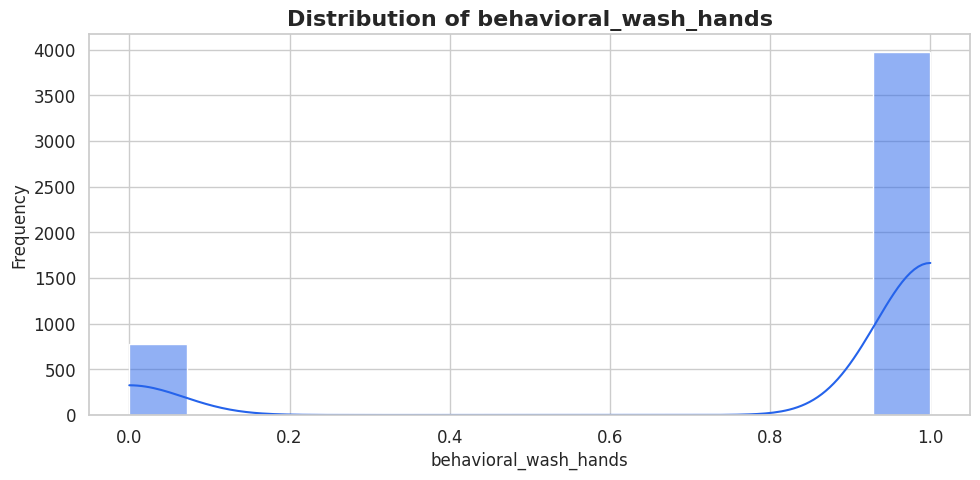

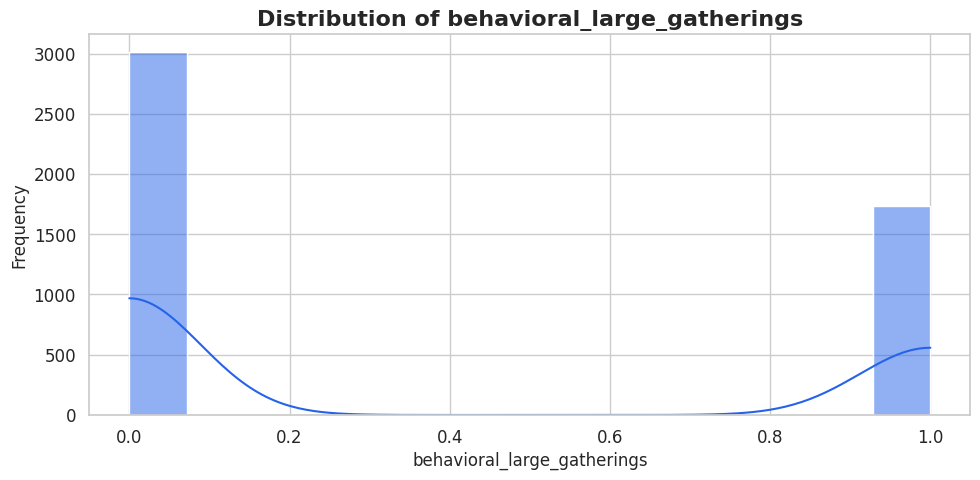

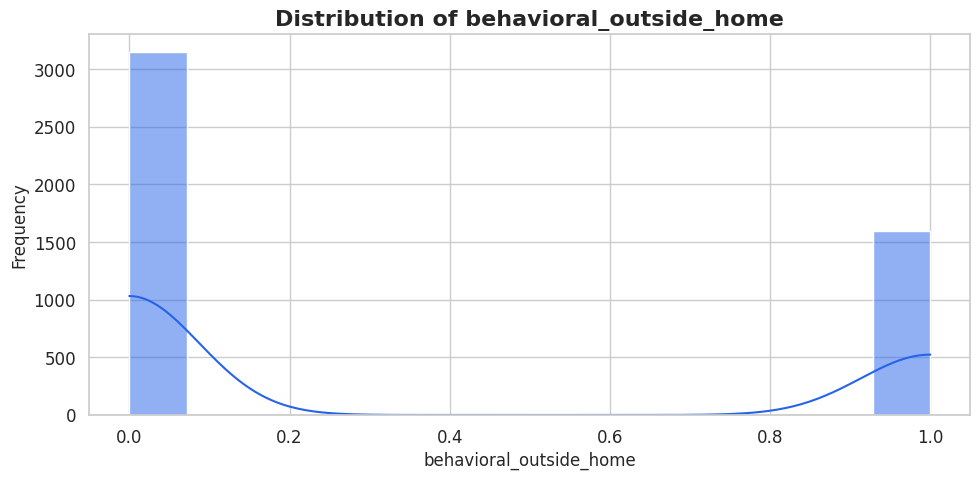

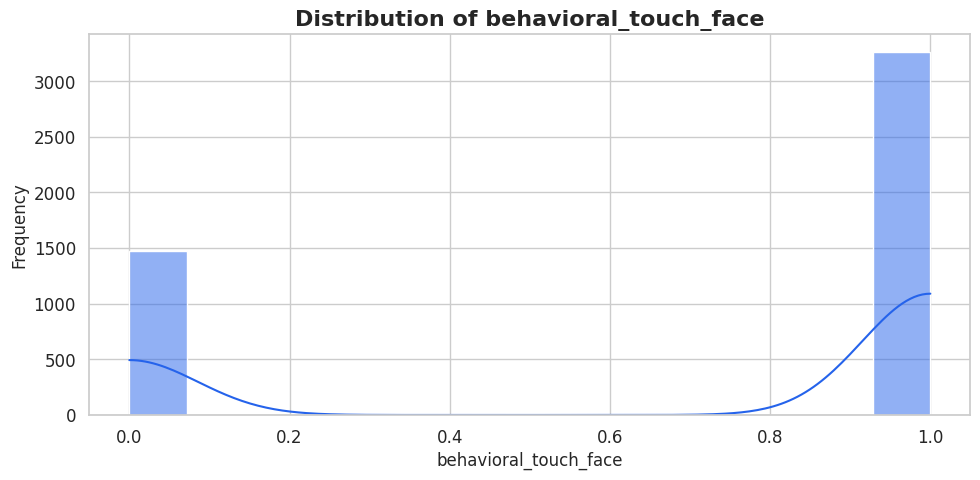

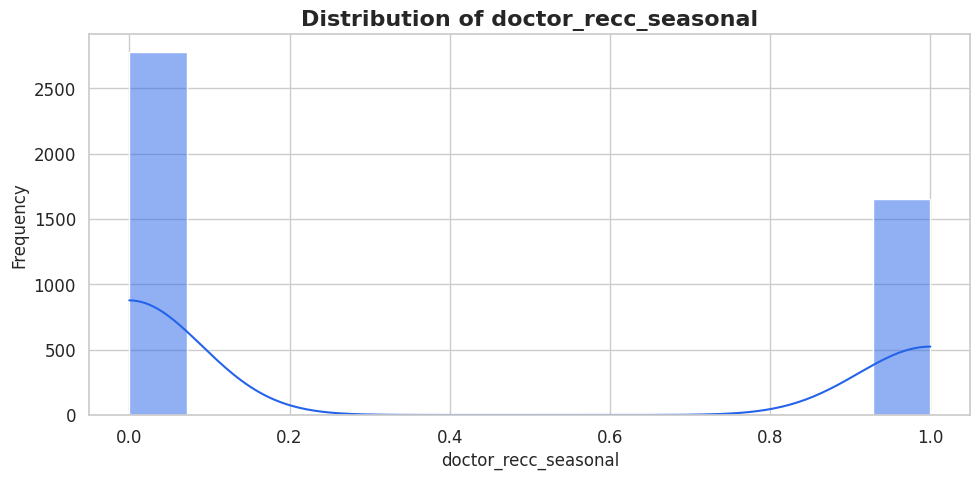

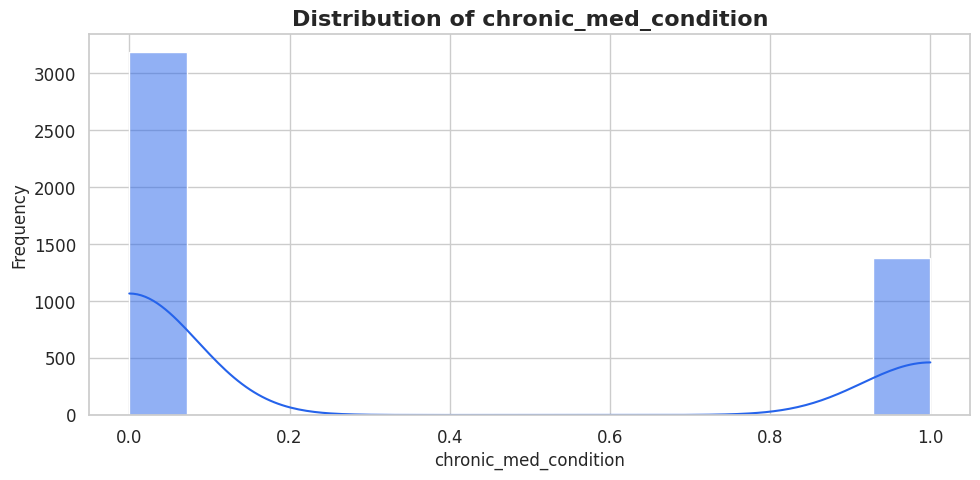

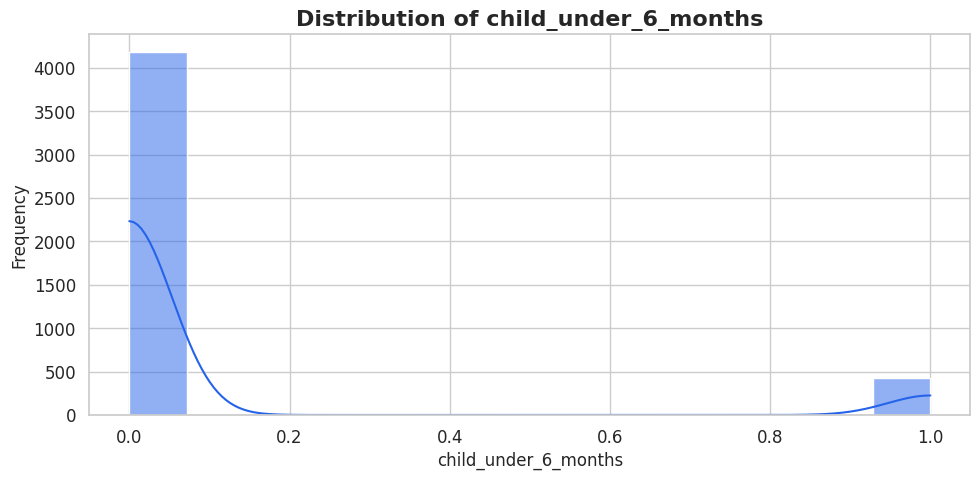

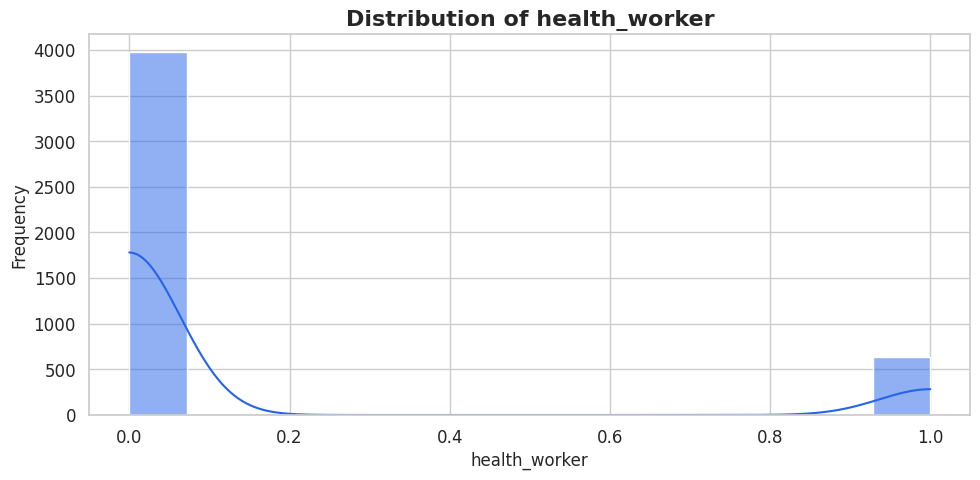

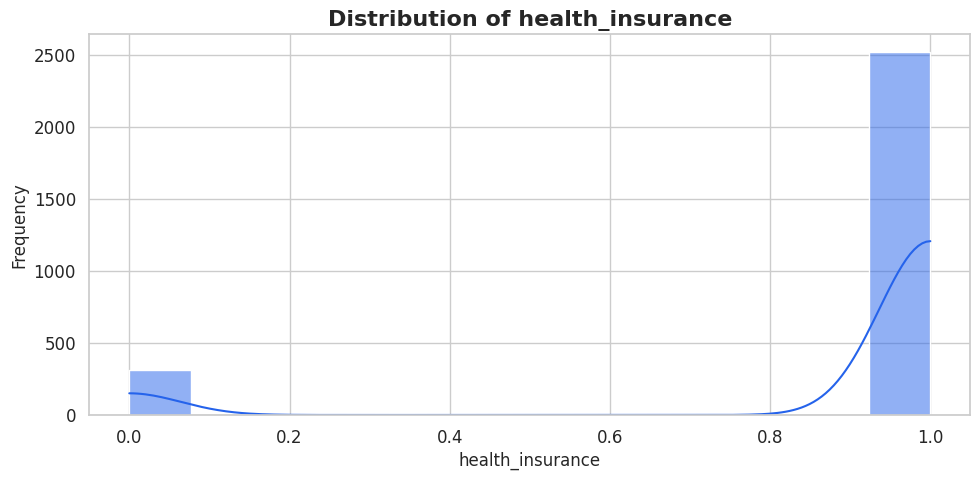

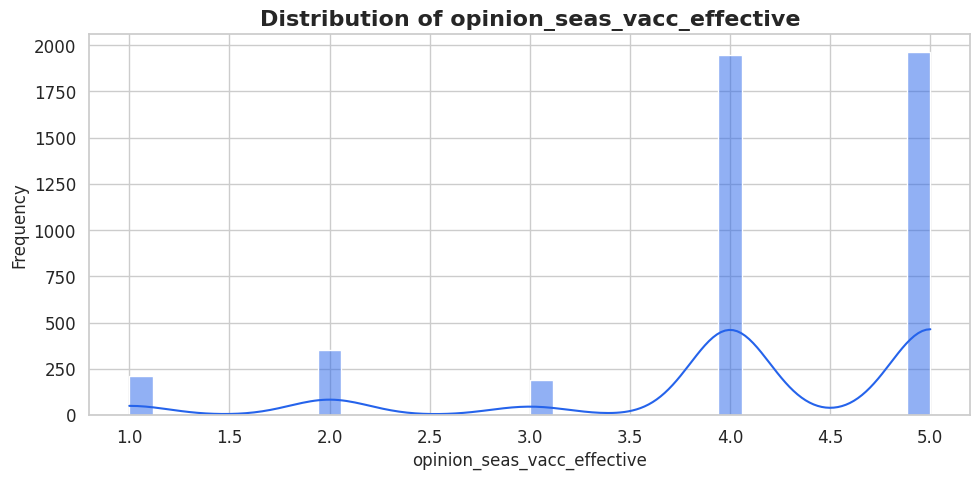

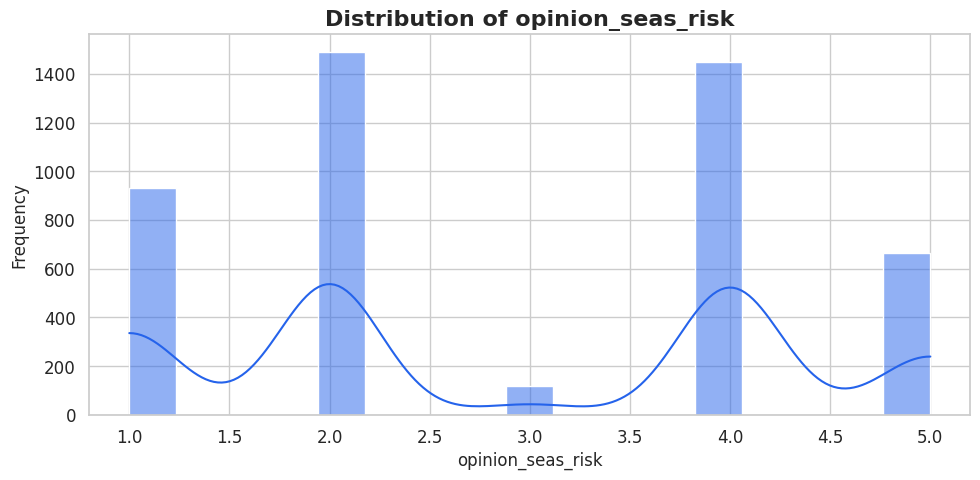

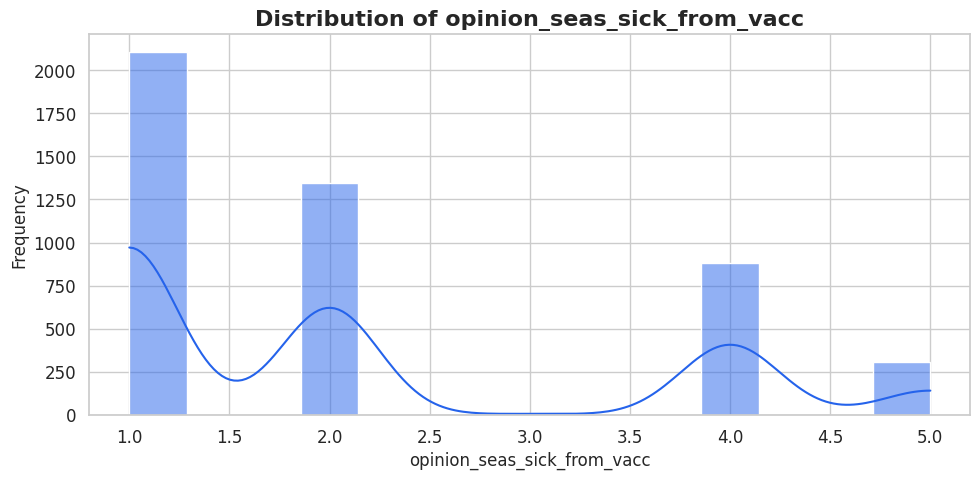

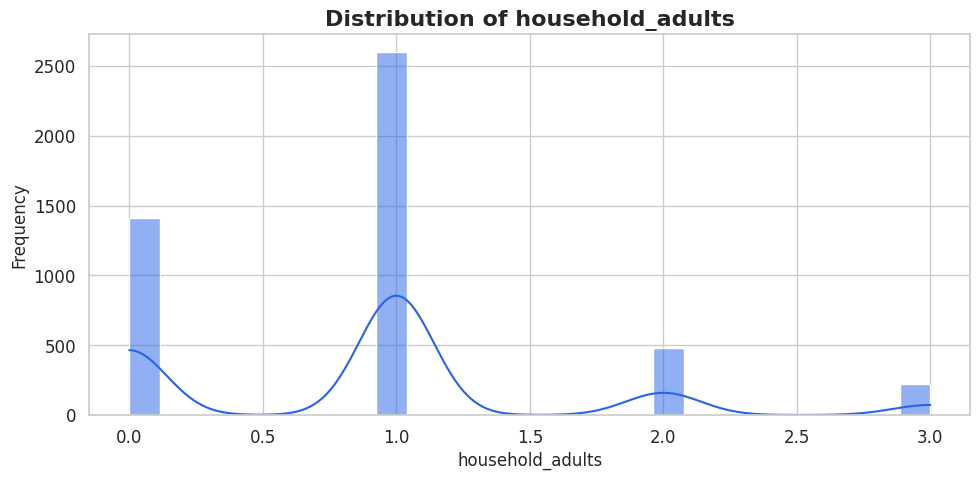

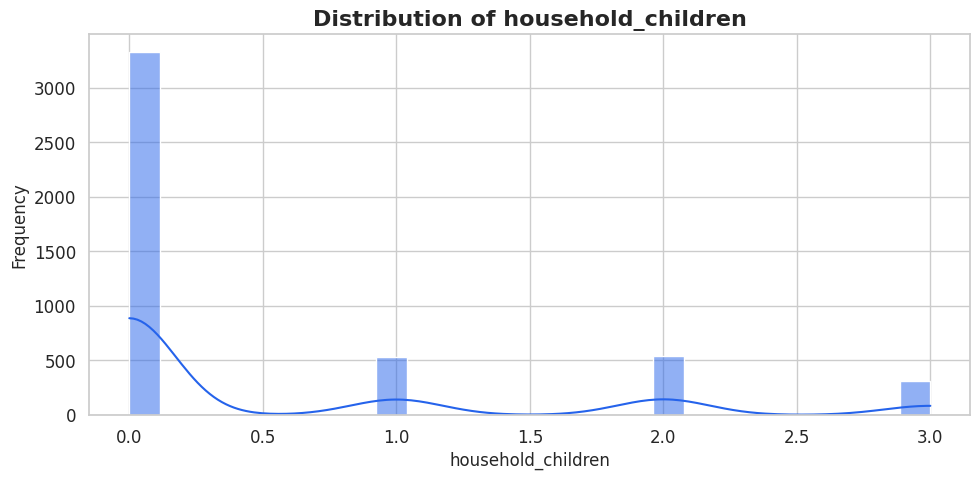

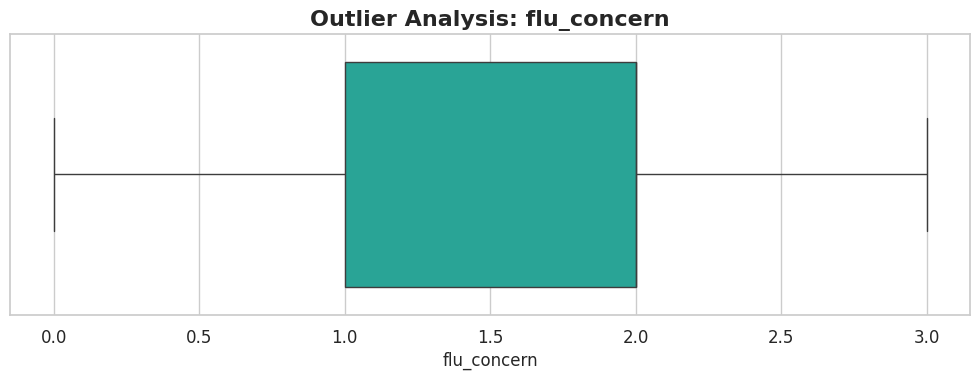

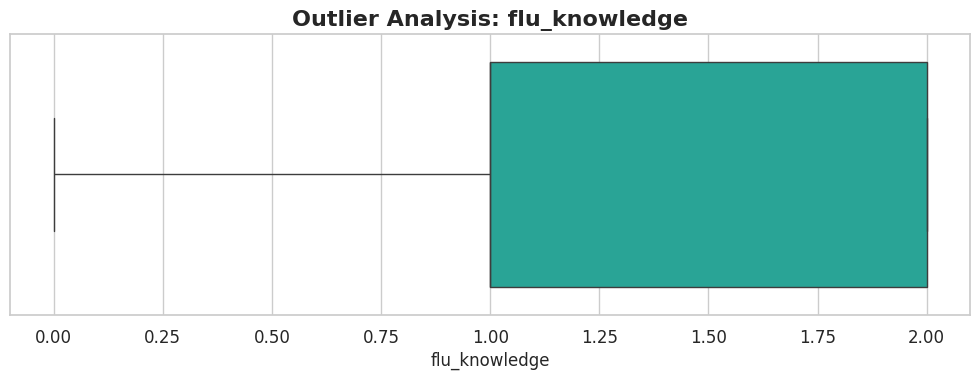

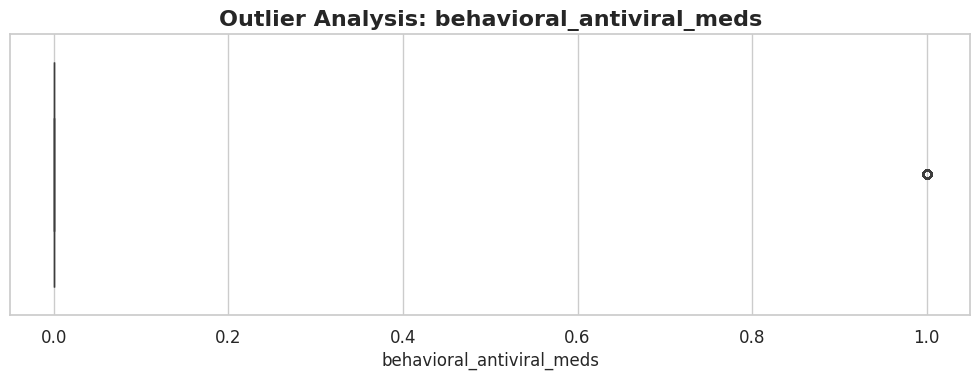

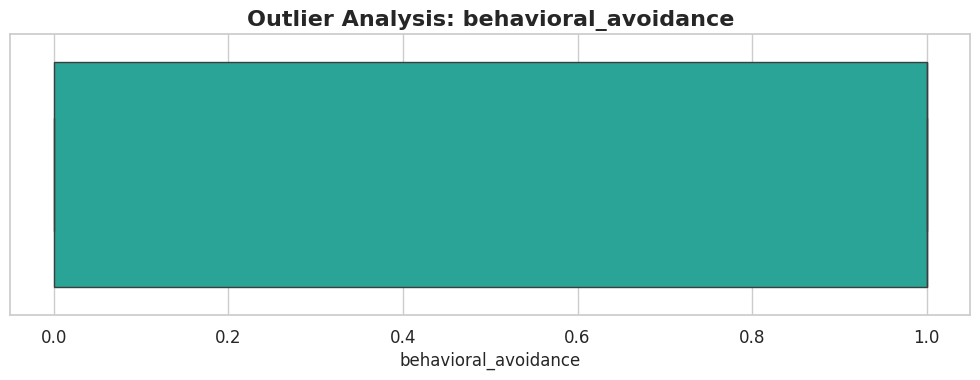

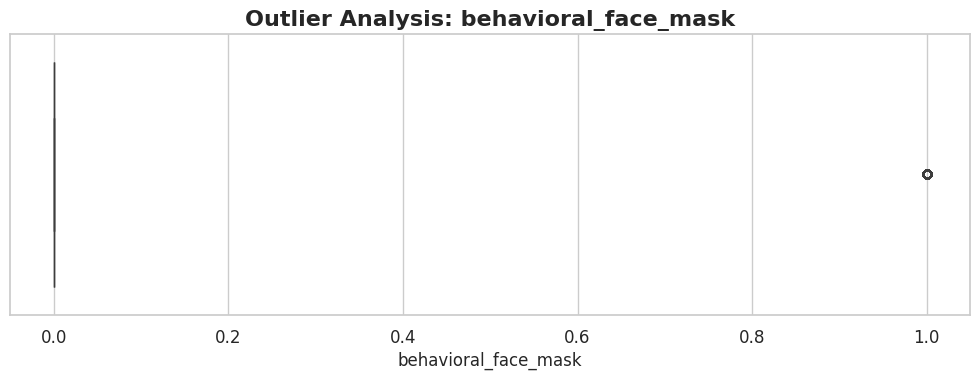

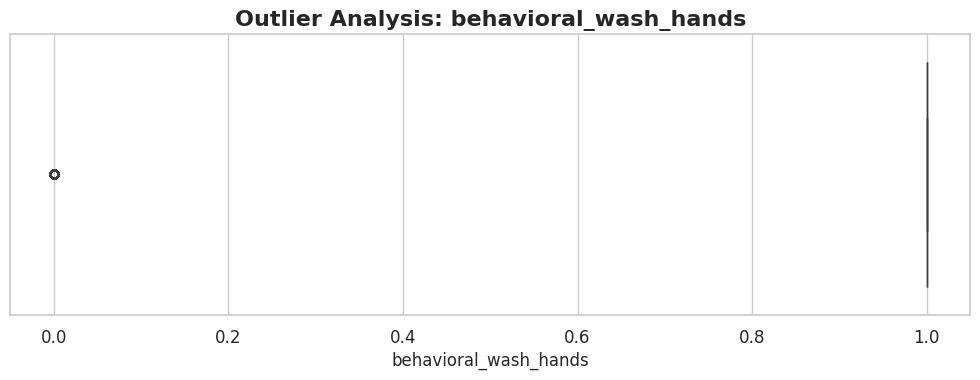

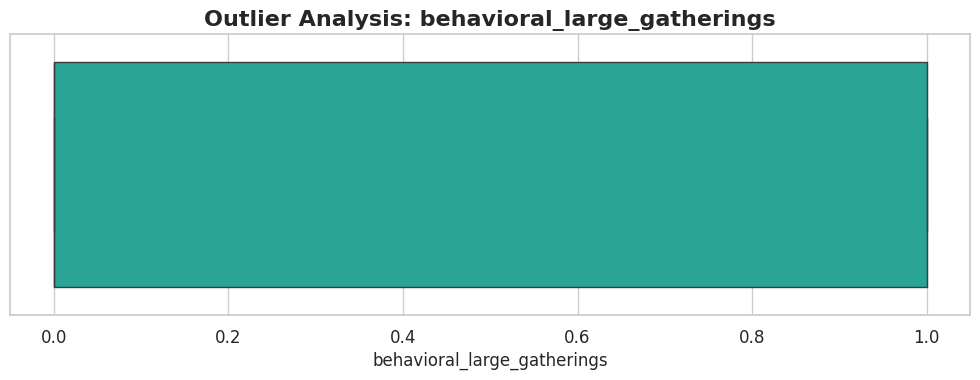

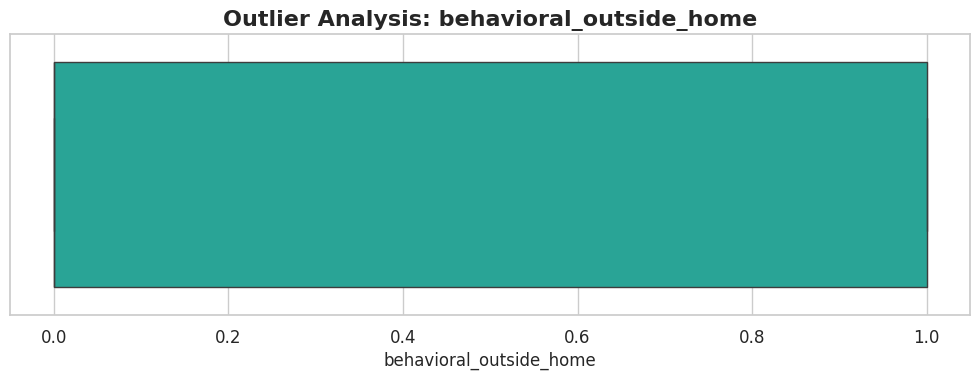

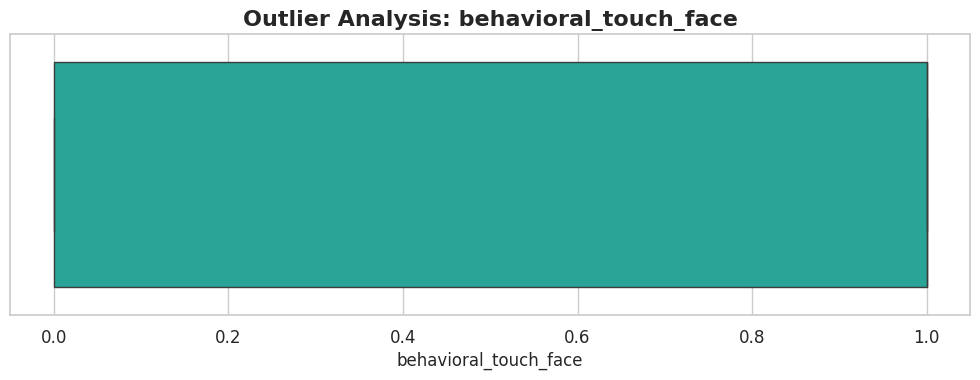

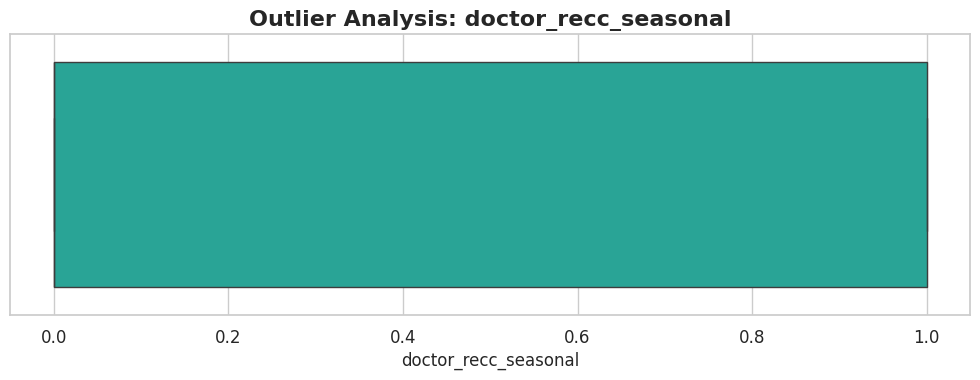

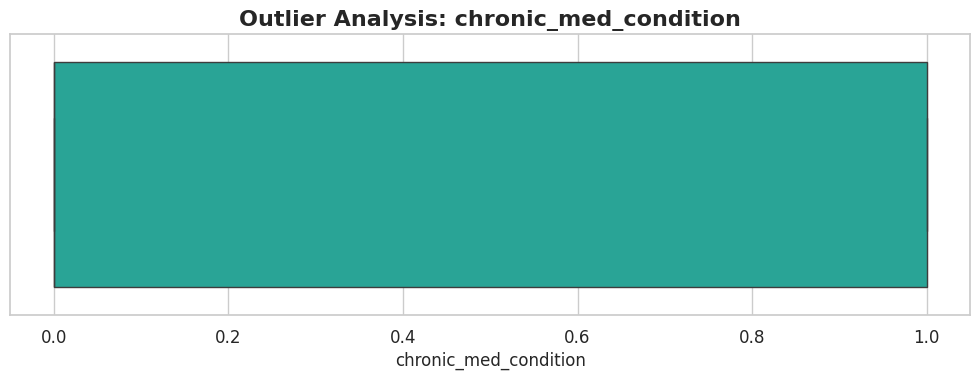

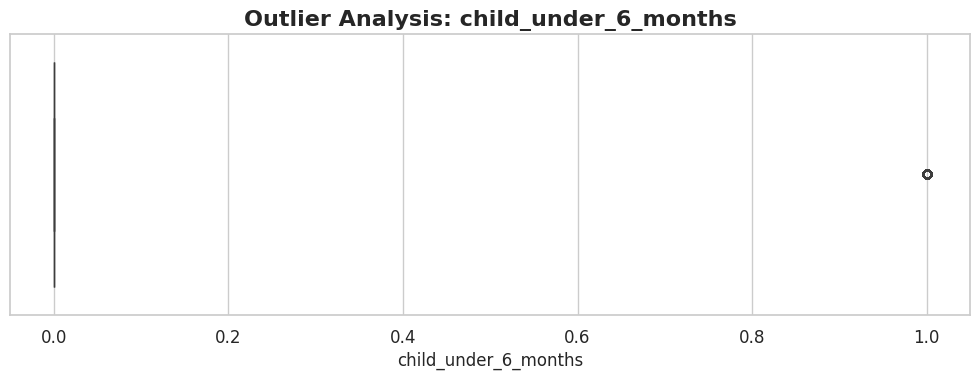

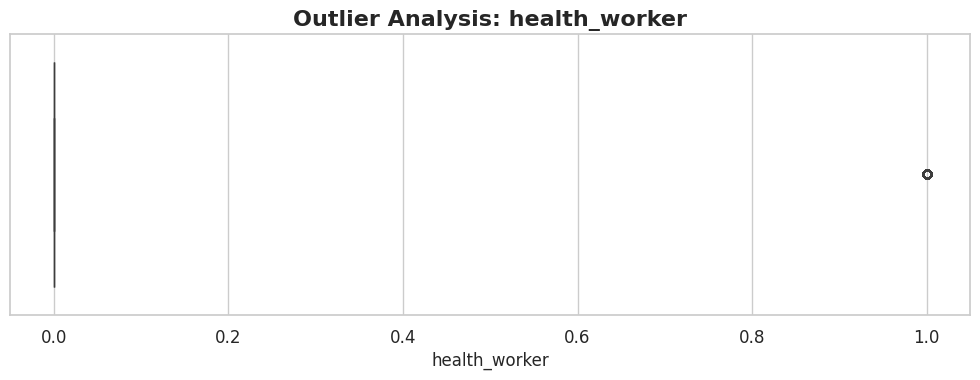

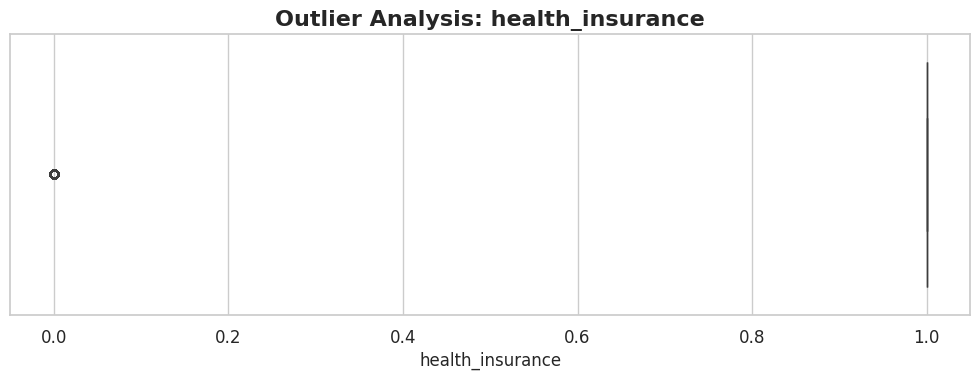

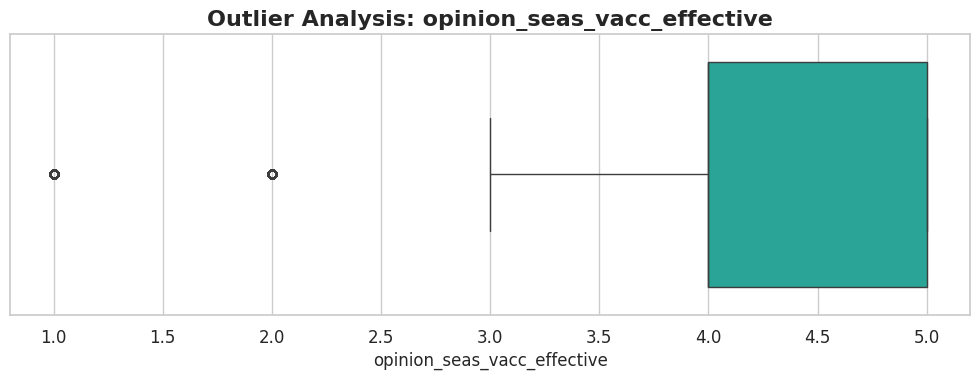

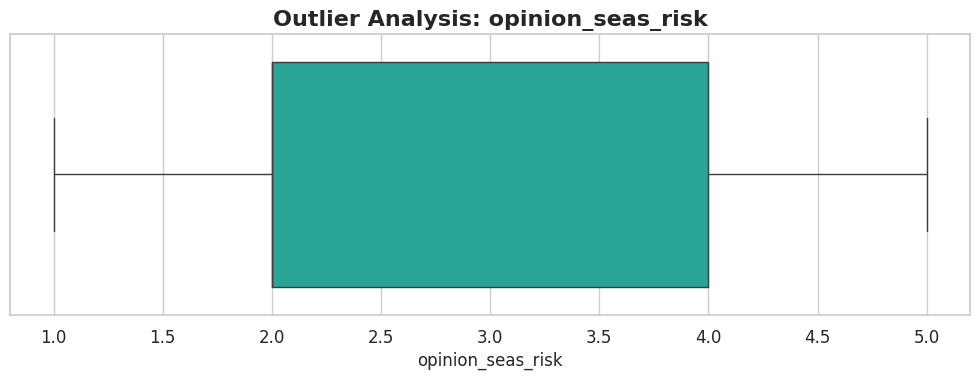

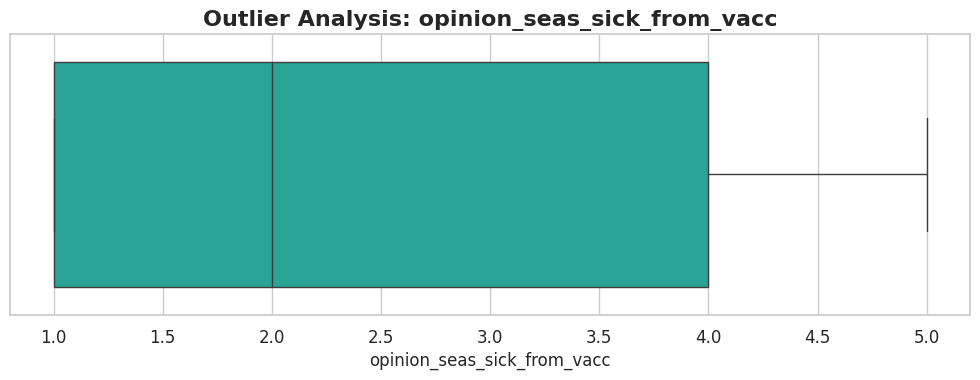

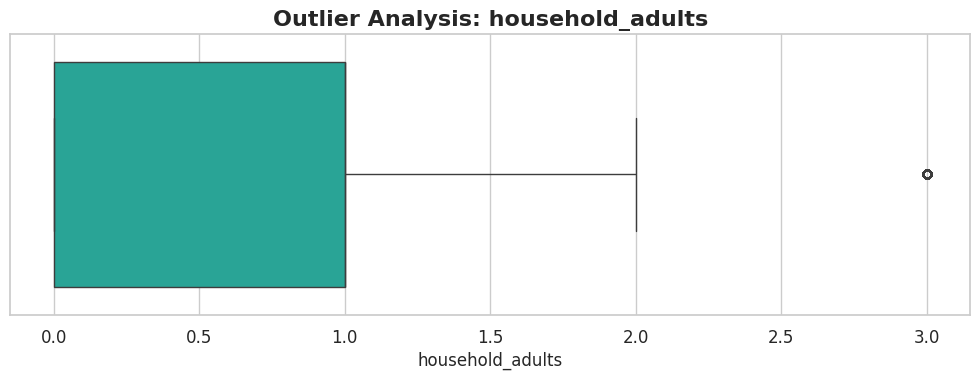

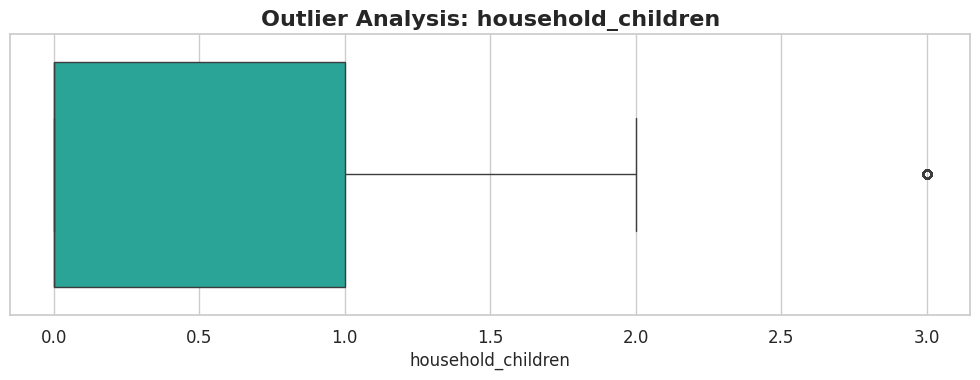

In [49]:
for col in num_cols:
    plt.figure(figsize=(10, 5))
    # Plot histogram to visualize distribution
    sns.histplot(train_df[col], kde=True, color="#2563EB")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(f"figures/distribution_{col}.png", dpi=300)
    plt.show()

for col in num_cols:
    plt.figure(figsize=(10, 4))
    # Plot boxplot to visualize outliers
    sns.boxplot(x=train_df[col], color="#14B8A6")
    plt.title(f"Outlier Analysis: {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.savefig(f"figures/boxplot_{col}.png", dpi=300)
    plt.show()

## Categorical Feature EDA

### Categorical Feature EDA

This section explores the distribution of categorical features by generating count plots for each. It orders the categories by their frequency (top 15) and saves each plot as a PNG image.

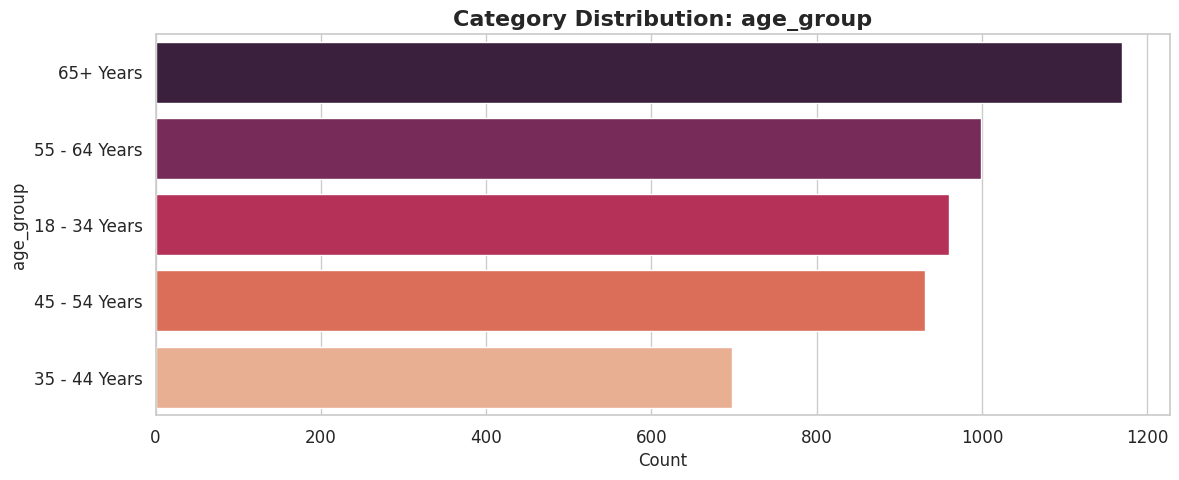

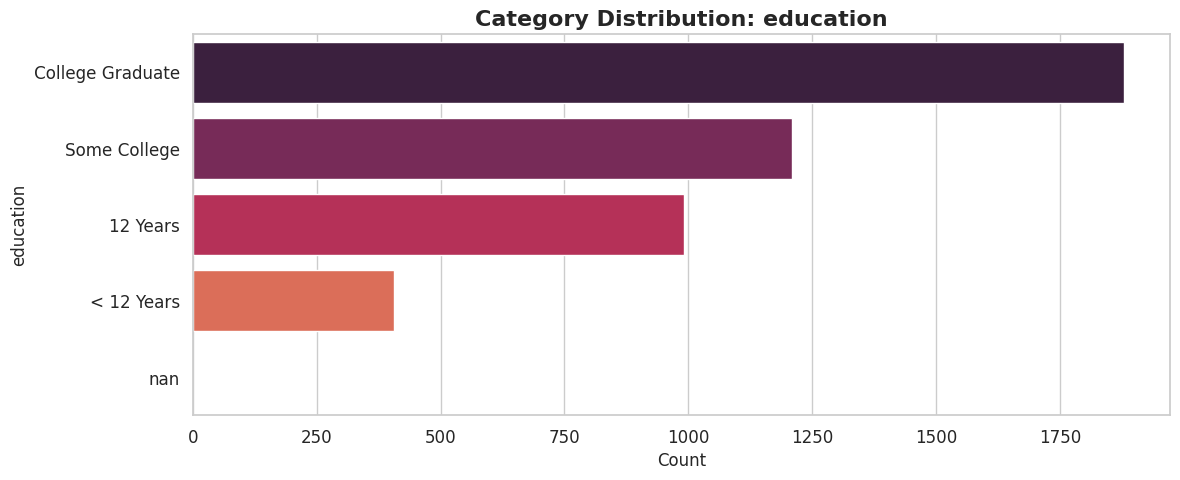

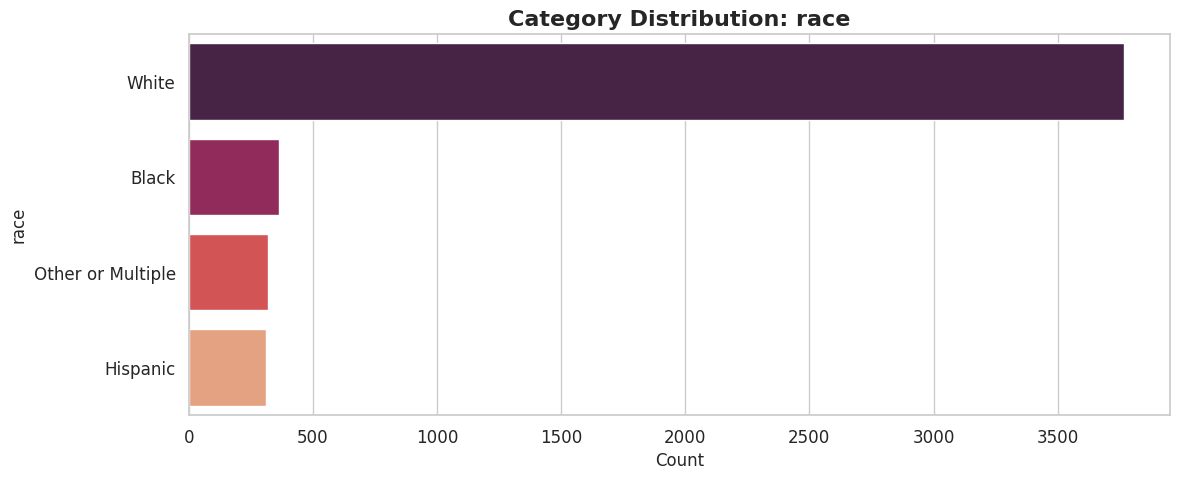

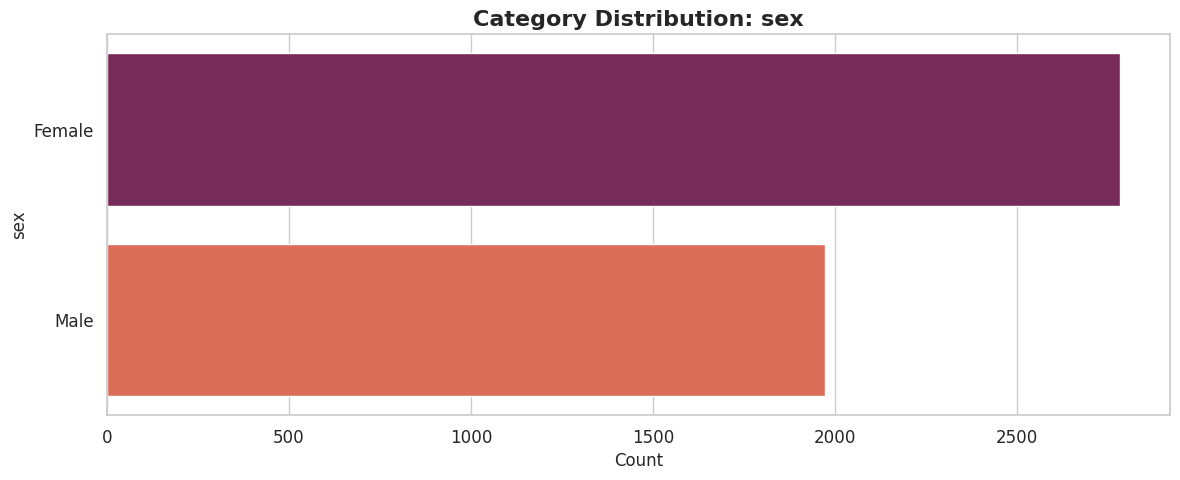

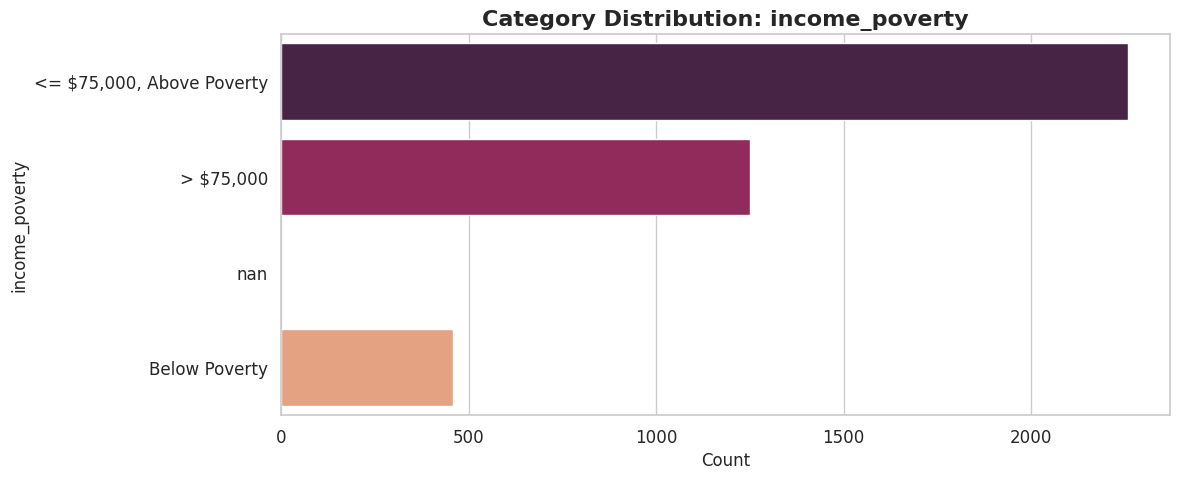

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(12, 5))
    # Get value counts for ordering, considering top 15 categories
    order = train_df[col].value_counts(dropna=False).head(15).index
    # Plot countplot for categorical distribution
    sns.countplot(data=train_df, y=col, order=order, palette="rocket")
    plt.title(f"Category Distribution: {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(f"figures/category_{col}.png", dpi=300)
    plt.show()

## Feature Vs Target ariables

## Feature vs. Target Variable Analysis

This section explores the relationship between individual features and the target variable. For numerical features, it uses box plots to show distributions by target class. For categorical features, it uses stacked bar plots to display the percentage distribution of the target variable within each category.

In [ ]:
for col in num_cols:
    plt.figure(figsize=(10, 5))
    # Box plot for numerical features against the target variable
    sns.boxplot(data=train_df, x=TARGET, y=col, palette="Set2")
    plt.title(f"{col} by Seasonal Vaccine Status")
    plt.xlabel("Seasonal Vaccine")
    plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(f"figures/target_relation_{col}.png", dpi=300)
    plt.show()

for col in cat_cols:
    # Create a cross-tabulation to see target distribution per category
    temp = pd.crosstab(train_df[col], train_df[TARGET], normalize="index") * 100
    # Plot as a stacked bar chart
    temp.plot(kind="bar", stacked=True, figsize=(12, 6))
    plt.title(f"{col} vs Seasonal Vaccine")
    plt.xlabel(col)
    plt.ylabel("Percentage")
    plt.legend(title="seasonal_vaccine")
    plt.tight_layout()
    plt.savefig(f"figures/categorical_target_{col}.png", dpi=300)
    plt.show()

## Correlation Analysis

### Correlation Analysis

This section computes and visualizes the correlation matrix for numerical features and the target variable. A heatmap is generated to show inter-feature correlations and correlations with the target. The correlations are also saved to CSV files.

In [ ]:
# Combine numerical columns and the target column for correlation analysis
corr_cols = num_cols + [TARGET]

# Calculate the pairwise correlation matrix
correlation_matrix = train_df[corr_cols].corr()

# Plot a heatmap of the correlation matrix
plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0, # Center the colormap at 0
    linewidths=0.5, # Add lines between cells
    annot=True, # Display correlation values on the heatmap
    fmt=".2f" # Format annotation values to 2 decimal places
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("figures/correlation_heatmap.png", dpi=300)
plt.show()

# Save the full correlation matrix to a CSV file
correlation_matrix.to_csv("outputs/correlation_matrix.csv")

# Extract and sort correlations with the target variable
target_corr = correlation_matrix[TARGET].sort_values(ascending=False)
display(target_corr)
target_corr.to_csv("outputs/target_correlations.csv")

## Data leakage check

## Data Leakage Check

This section performs a basic check for potential data leakage by identifying columns whose names contain suspicious keywords commonly associated with target or outcome variables. These columns are flagged for manual review.

In [ ]:
# List to store columns that might indicate data leakage
possible_leakage = []

# Iterate through all columns in the training DataFrame
for col in train_df.columns:
    # Skip the actual target column
    if col == TARGET:
        continue

    # Convert column name to lowercase for case-insensitive checking
    col_lower = col.lower()
    # Define a list of suspicious keywords
    suspicious_words = ["target", "label", "result", "outcome", "final", "score", "prediction"]

    # Check if any suspicious word is in the column name
    if any(word in col_lower for word in suspicious_words):
        possible_leakage.append(col)

print("Possible leakage columns to review manually:")
print(possible_leakage)

# Save the list of possible leakage columns to a text file
with open("outputs/possible_leakage_columns.txt", "w") as f:
    f.write(str(possible_leakage))

## Preparing Features and Targets

## Preparing Features and Targets

This section separates the features (X) and the target (y) from the training data. It also prepares the test features and ensures that both training and testing feature sets have consistent columns. Finally, it re-identifies numerical and categorical features for preprocessing.

In [ ]:
# Separate features (X) and target (y) from the training DataFrame
X = train_df.drop(columns=[TARGET, ID_COL])
y = train_df[TARGET].astype(int) # Ensure target is integer type

# Extract IDs and features from the test DataFrame
test_ids = test_df[ID_COL]
test_features = test_df.drop(columns=[ID_COL])

# Align columns of test_features with X to ensure consistency
# Missing columns in test_features will be filled with NaN
test_features = test_features.reindex(columns=X.columns, fill_value=np.nan)

# Re-identify numerical and categorical features after dropping ID and TARGET columns
num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Final numerical features:", len(num_features))
print(num_features)

print("Final categorical features:", len(cat_features))
print(cat_features)

## Preprocessing pipeline

### Preprocessing Pipeline

This section defines a comprehensive preprocessing pipeline using `ColumnTransformer` from scikit-learn. It includes:
-   **Numerical Transformer**: Imputes missing numerical values with the median and scales features using `StandardScaler`.
-   **Categorical Transformer**: Imputes missing categorical values with the most frequent value and encodes them using `OneHotEncoder`.

In [ ]:
# Pipeline for numerical feature preprocessing
# 1. Impute missing values with the median
# 2. Scale features using StandardScaler
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline for categorical feature preprocessing
# 1. Impute missing values with the most frequent value
# 2. One-hot encode categorical features
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")) # handle_unknown='ignore' prevents errors on unseen categories
])

# Combine numerical and categorical transformers using ColumnTransformer
# This applies different transformers to different columns
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features)
])

## Train Validation splits

## Train-Validation Splits

This section splits the training data into training and validation sets. A `stratify` parameter is used to maintain the same proportion of target classes in both splits, which is crucial for imbalanced datasets. The shapes of the resulting sets are printed for verification.

In [ ]:
# Split the data into training and validation sets
# test_size=0.2 means 20% of data for validation
# random_state for reproducibility
# stratify=y ensures class proportions are maintained in both sets
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Validation shape:", X_valid.shape)

## Defining Models

## Defining Models

This section initializes a dictionary of various classification models, including traditional machine learning algorithms like Logistic Regression and Decision Tree, as well as ensemble methods like Random Forest, Gradient Boosting, XGBoost, LightGBM, and CatBoost. Each model is configured with a `random_state` for reproducibility and some with specific parameters like `n_estimators` or `learning_rate`.

In [ ]:
# Define a dictionary of models to be trained and evaluated
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000), # Increased max_iter for convergence
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=300), # Increased n_estimators
    "Extra Trees": ExtraTreesClassifier(random_state=42, n_estimators=300), # Increased n_estimators
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss", # Evaluation metric for binary classification
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5
    ),
    "LightGBM": LGBMClassifier(
        random_state=42,
        n_estimators=300,
        learning_rate=0.05
    ),
    "CatBoost": CatBoostClassifier(
        random_state=42,
        verbose=0, # Suppress verbose output during training
        iterations=300,
        learning_rate=0.05
    )
}

## Model Evaluation Function

## Model Evaluation Function

This section defines a function `evaluate_model` that takes a model name and the model object as input. It constructs a pipeline with the preprocessor and the given model, trains it on the training data, makes predictions on the validation data, and then calculates and returns various classification metrics (Accuracy, Precision, Recall, F1-Score, ROC-AUC). It also returns the trained pipeline.

In [ ]:
def evaluate_model(name, model):
    # Create a pipeline combining preprocessing and the model
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Fit the pipeline on the training data
    pipeline.fit(X_train, y_train)

    # Make predictions and predict probabilities on the validation set
    preds = pipeline.predict(X_valid)
    probs = pipeline.predict_proba(X_valid)[:, 1] # Probability of the positive class

    # Calculate various evaluation metrics
    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_valid, preds),
        "Precision": precision_score(y_valid, preds, zero_division=0),
        "Recall": recall_score(y_valid, preds, zero_division=0),
        "F1": f1_score(y_valid, preds, zero_division=0),
        "ROC_AUC": roc_auc_score(y_valid, probs) # ROC AUC score for probability predictions
    }

    return result, pipeline

## Training and Comparing Models

## Training and Comparing Models

This section iterates through the predefined models, trains each one using the `evaluate_model` function, and stores their performance metrics. It captures any errors during training and finally displays a sorted DataFrame of all model results, saving it to a CSV file.

In [ ]:
# Lists to store evaluation results and trained pipelines
results = []
trained_pipelines = {}

# Loop through each model defined in the 'models' dictionary
for name, model in models.items():
    print(f"Training {name}...")

    try:
        # Evaluate the model and store its results and pipeline
        result, pipeline = evaluate_model(name, model)
        results.append(result)
        trained_pipelines[name] = pipeline

    except Exception as error:
        print(f"{name} failed:", error)

# Convert results list to DataFrame and sort by ROC_AUC and F1 score
results_df = pd.DataFrame(results).sort_values(["ROC_AUC", "F1"], ascending=False)

# Display the sorted results and save to CSV
display(results_df)
results_df.to_csv("outputs/model_results.csv", index=False)

## Model performance Visualisation

## Model Performance Visualization

This section visualizes the performance of the trained models. It generates two bar plots: one comparing models by their ROC-AUC score and another by their F1 score. Both plots are saved as PNG images.

In [ ]:
# Plot model comparison based on ROC-AUC
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="ROC_AUC", y="Model", palette="viridis")
plt.title("Model Comparison by ROC-AUC")
plt.xlabel("ROC-AUC")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig("figures/model_comparison_roc_auc.png", dpi=300)
plt.show()

# Plot model comparison based on F1 Score
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="F1", y="Model", palette="mako")
plt.title("Model Comparison by F1 Score")
plt.xlabel("F1 Score")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig("figures/model_comparison_f1.png", dpi=300)
plt.show()

## Cross Validation for 5 models

## Cross-Validation for Top Models

This section performs stratified K-fold cross-validation on the top 5 performing models identified earlier. It calculates the mean and standard deviation of the ROC-AUC scores across the folds to provide a more robust estimate of model performance. The results are displayed and saved to a CSV file.

In [ ]:
# Get the names of the top 5 models based on previous validation results
top_models = results_df["Model"].head(5).tolist()
cv_results = []

# Define Stratified K-Fold cross-validation for balanced splits
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation for each of the top models
for model_name in top_models:
    model = models[model_name]

    # Create a pipeline for the current model
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Get cross-validation scores using ROC-AUC as the metric
    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1 # Use all available CPU cores
    )

    # Store the mean and standard deviation of the CV scores
    cv_results.append({
        "Model": model_name,
        "CV ROC-AUC Mean": scores.mean(),
        "CV ROC-AUC Std": scores.std()
    })

# Convert CV results to DataFrame and sort by mean ROC-AUC
cv_results_df = pd.DataFrame(cv_results).sort_values("CV ROC-AUC Mean", ascending=False)

display(cv_results_df)
cv_results_df.to_csv("outputs/cross_validation_results.csv", index=False)

## Best Model Analysis

## Best Model Analysis

This section identifies the best performing model from the initial validation phase. It then generates a detailed classification report and a confusion matrix to assess its performance on the validation set. An ROC curve is also plotted to visualize the trade-off between true positive rate and false positive rate.

In [ ]:
# Identify the best model based on previous validation results
best_model_name = results_df.iloc[0]["Model"]
best_pipeline = trained_pipelines[best_model_name]

print("Best validation model:", best_model_name)

# Make predictions and get probabilities on the validation set using the best model
valid_preds = best_pipeline.predict(X_valid)
valid_probs = best_pipeline.predict_proba(X_valid)[:, 1]

# Generate and print the classification report
report = classification_report(y_valid, valid_preds)
print(report)

# Save the classification report to a text file
with open("outputs/classification_report.txt", "w") as f:
    f.write(report)

In [ ]:
# Generate the confusion matrix
cm = confusion_matrix(y_valid, valid_preds)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("figures/confusion_matrix.png", dpi=300)
plt.show()

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_valid, valid_probs)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--") # Plot the random classifier line
plt.title(f"ROC Curve - {best_model_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("figures/roc_curve.png", dpi=300)
plt.show()

## Hyperparameter Tuning - XGBoost

## Hyperparameter Tuning - XGBoost

This section performs hyperparameter tuning for the XGBoost model using `RandomizedSearchCV`. It defines a parameter distribution for various XGBoost parameters and searches for the best combination that maximizes the ROC-AUC score using cross-validation. The best parameters and score are printed and saved to a JSON file, and the tuned model is stored.

In [ ]:
# Initialize XGBoost Classifier for tuning
tuning_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

# Create a pipeline for tuning, including the preprocessor
tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", tuning_model)
])

# Perform Randomized Search Cross-Validation
search = RandomizedSearchCV(
    tuning_pipeline,
    param_distributions=param_dist,
    n_iter=20, # Number of parameter settings that are sampled
    scoring="roc_auc", # Metric to optimize
    cv=3, # 3-fold cross-validation
    random_state=42,
    n_jobs=-1, # Use all available CPU cores
    verbose=1 # Display progress
)

search.fit(X_train, y_train)

print("Best XGBoost parameters:")
print(search.best_params_)

print("Best XGBoost CV ROC-AUC:")
print(search.best_score_)

# Store the best estimator found by RandomizedSearchCV
tuned_model = search.best_estimator_

# Save the best parameters to a JSON file
with open("outputs/tuned_xgboost_params.json", "w") as f:
    json.dump(search.best_params_, f, indent=4)

## TUNED MODEL PERFORMANCE

## Tuned Model Performance

This section evaluates the performance of the hyperparameter-tuned XGBoost model on the validation set. It calculates and displays various classification metrics and saves them to a CSV file, providing a comparison against the untuned models.

In [ ]:
# Make predictions and predict probabilities using the tuned model
tuned_preds = tuned_model.predict(X_valid)
tuned_probs = tuned_model.predict_proba(X_valid)[:, 1]

# Calculate evaluation metrics for the tuned model
tuned_result = {
    "Model": "Tuned XGBoost",
    "Accuracy": accuracy_score(y_valid, tuned_preds),
    "Precision": precision_score(y_valid, tuned_preds, zero_division=0),
    "Recall": recall_score(y_valid, tuned_preds, zero_division=0),
    "F1": f1_score(y_valid, tuned_preds, zero_division=0),
    "ROC_AUC": roc_auc_score(y_valid, tuned_probs)
}

# Display the results of the tuned model in a DataFrame
display(pd.DataFrame([tuned_result]))
pd.DataFrame([tuned_result]).to_csv("outputs/tuned_model_result.csv", index=False)

## PERMUTATION IMPORTANCE

## Permutation Importance

This section calculates and visualizes feature importances using permutation importance. This method measures the decrease in a model's score when a single feature's values are randomly shuffled, indicating how much the model relies on that feature. The top 20 most important features are displayed and saved to a CSV file and a bar plot.

In [ ]:
# Calculate permutation importance for the best model
# n_repeats: number of times to shuffle a feature and re-evaluate
# scoring: metric to use for evaluating performance impact
perm = permutation_importance(
    best_pipeline,
    X_valid,
    y_valid,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="roc_auc"
)

# Create a DataFrame for feature importances and sort them
importance_df = pd.DataFrame({
    "Feature": X_valid.columns,
    "Importance": perm.importances_mean
}).sort_values("Importance", ascending=False)

# Display the top 20 most important features
display(importance_df.head(20))
importance_df.to_csv("outputs/permutation_importance.csv", index=False)

In [ ]:
# Plot the top 20 feature importances
plt.figure(figsize=(12, 7))
sns.barplot(data=importance_df.head(20), x="Importance", y="Feature", palette="mako")
plt.title("Top 20 Feature Importances")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("figures/permutation_importance.png", dpi=300)
plt.show()

## Explainable SHAP AI

## Explainable SHAP AI

This section uses SHAP (SHapley Additive exPlanations) to interpret the predictions of the best model. SHAP values help in understanding the contribution of each feature to a model's prediction for individual instances and the overall impact of features. It preprocesses the validation data, creates a SHAP explainer, calculates SHAP values, and generates a summary plot for the top features. Error handling is included for robustness.

In [ ]:
try:
    # Transform validation data using preprocessing pipeline
    X_valid_processed = best_pipeline.named_steps["preprocessor"].transform(X_valid)

    # Get actual transformed feature names
    feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()

    # Extract trained model only
    model_only = best_pipeline.named_steps["model"]

    # Create SHAP explainer
    explainer = shap.Explainer(model_only)

    # Calculate SHAP values
    shap_values = explainer(X_valid_processed[:300])

    # Convert processed data into DataFrame with real names
    X_valid_processed_df = pd.DataFrame(
        X_valid_processed[:300],
        columns=feature_names
    )

    # SHAP summary plot with REAL feature names
    shap.summary_plot(
        shap_values,
        X_valid_processed_df,
        max_display=20,
        show=True
    )

except Exception as error:
    print("SHAP failed.")
    print(error)

## CREATING TOP 5 SUBMISSION FILES

## Creating Top 5 Submission Files

This section generates submission files for the top 5 models based on their validation performance. For each of these models, it predicts the target variable on the unseen test dataset, creates a submission DataFrame with `respondent_id` and `seasonal_vaccine` columns, and saves it to a CSV file with a structured naming convention including the group number and rank.

In [ ]:
 GROUP_NUMBER = "B"

# Select top 5 models from validation performance
top_5_models = results_df.sort_values(
    ["ROC_AUC", "F1"],
    ascending=False
)["Model"].head(5).tolist()

print("Top 5 selected models:")
print(top_5_models)

for rank, model_name in enumerate(top_5_models, start=1):

    # Get trained model pipeline
    model_pipeline = trained_pipelines[model_name]

    # Predict target for testing dataset
    test_predictions = model_pipeline.predict(test_features)

    # Create required submission format
    submission = pd.DataFrame({
        "respondent_id": test_ids,
        "seasonal_vaccine": test_predictions.astype(int)
    })

    # Save CSV in required naming format
    filename = f"submissions/challenge_submission_group_{GROUP_NUMBER}_order_{rank}.csv"
    submission.to_csv(filename, index=False)

    print(f"Saved {filename}")
    display(submission.head())

In [ ]:
!zip -r submissions.zip submissions